# Where are the k-mers? Carrier axis vs bubble-size axis

**Created 2026-05-29.** Companion to `CN_FULL_COMPOSITION_v3qc_v3.ipynb`.

**Claim being tested.** The cactus/PG k-mer imbalance is *not* on the bubble-size
axis (cactus does not sit in bigger bubbles — the `m_b` distributions overlap).
It lives on the **carrier axis**: within identically-sized bubbles, cactus
founders' reconstructed haplotypes activate the **rare-allele tag** k-mers, while
PG founders activate the **common / REF tag** k-mers. The `m_b` plot integrates
over carriers, so it is blind to this; you only see it when you condition on
carrier identity.

We use `ac_k` = number of founders carrying k-mer *k* as a direct proxy for
"how common is the allele this k-mer tags": a k-mer carried by few founders tags
a rare allele; one carried by many tags a common allele.

> **Caveat (read first).** This matrix `data/cn_full_231_v3qc_v3/` was built with
> `--treat-missing-as-n` **ON** (verified from its build log). N-poisoning of PG
> missing GTs inflates the magnitude of the carrier-axis skew shown here. The
> *qualitative* point of this notebook — that the imbalance is on the carrier
> axis, not the bubble-size axis — holds regardless of N-on/N-off; only the size
> of the gap is confounded. Re-run on an N-off matrix to get the artifact-free
> magnitude.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import load_npz

ROOT = Path('/global/scratch/users/tbellg/kmate')
CN_PATH   = ROOT / 'data/cn_full_231_v3qc_v3/cn_Chr1.cn.npz'
META_PATH = ROOT / 'data/cn_full_231_v3qc_v3/cn_Chr1.meta.npz'
SPLIT     = ROOT / 'data/founder_split_cactus_pg.json'
PLOTDIR   = ROOT / 'notebooks/plots'; PLOTDIR.mkdir(exist_ok=True)

cn = load_npz(CN_PATH).tocsr()
F, K = cn.shape
print(f'cn_full Chr1: shape=({F}, {K:,}) nnz={cn.nnz:,}')

meta = np.load(META_PATH, allow_pickle=True)
founders = np.asarray(meta['founders']).astype(str)
with open(SPLIT) as f:
    split = json.load(f)
cactus_set = set(map(str, split['cactus'])); pg_set = set(map(str, split['PG']))
is_cactus = np.array([f in cactus_set for f in founders])
is_pg     = np.array([f in pg_set     for f in founders])
n_cactus, n_pg = int(is_cactus.sum()), int(is_pg.sum())
BASELINE = n_cactus / (n_cactus + n_pg)   # cactus share of the panel
print(f'cactus={n_cactus}, PG={n_pg}, panel cactus-share baseline = {BASELINE:.3f}')

cn_full Chr1: shape=(231, 22,673,541) nnz=516,782,103
cactus=80, PG=151, panel cactus-share baseline = 0.346


In [2]:
# Per-k-mer carrier counts and the carrier split
ac        = np.asarray(cn.sum(axis=0)).flatten()                 # total carriers
ac_cactus = np.asarray(cn[is_cactus, :].sum(axis=0)).flatten()   # cactus carriers
ac_pg     = np.asarray(cn[is_pg, :].sum(axis=0)).flatten()       # PG carriers
assert np.all(ac == ac_cactus + ac_pg)

# Per-k-mer bubble size m_b
bubble_id = np.asarray(meta['bubble_id']).astype(np.int64)
mb_per_bubble = np.bincount(bubble_id)
m_b = mb_per_bubble[bubble_id]                                   # bubble size of each k-mer

# Restrict to k-mers actually carried by >=1 founder (ac>0); ac=0 are dead
live = ac > 0
print(f'live k-mers (ac>0): {live.sum():,} / {K:,}')
print(f'  cactus-share of carriers, rare tags (ac<=5):   {ac_cactus[live & (ac<=5)].sum()/ac[live & (ac<=5)].sum():.3f}')
print(f'  cactus-share of carriers, common tags (ac>=50): {ac_cactus[live & (ac>=50)].sum()/ac[live & (ac>=50)].sum():.3f}')
print(f'  (panel baseline = {BASELINE:.3f})')

live k-mers (ac>0): 17,616,505 / 22,673,541
  cactus-share of carriers, rare tags (ac<=5):   0.621
  cactus-share of carriers, common tags (ac>=50): 0.342
  (panel baseline = 0.346)


## Panel A — "Same bubbles": the `m_b` view is blind to the imbalance

Distribution of bubble size (`m_b`) for the k-mers each side *carries*. The two
distributions overlap; medians are ~equal. Looking only at this, you'd conclude
there is no cactus/PG asymmetry — cactus founders do not sit in bigger bubbles.

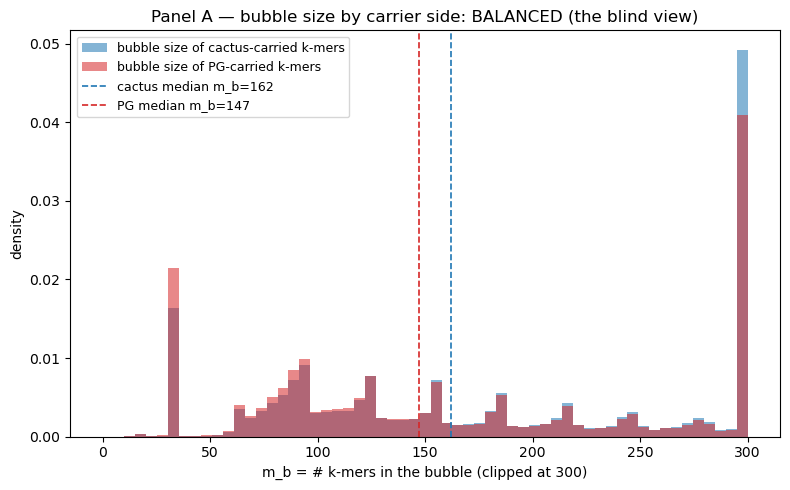

In [3]:
cac_k = ac_cactus > 0          # k-mers carried by >=1 cactus founder
pg_k  = ac_pg     > 0          # k-mers carried by >=1 PG founder

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, 300, 60)
ax.hist(np.clip(m_b[cac_k], 0, 300), bins=bins, density=True, alpha=0.55,
        color='#1f77b4', label=f'bubble size of cactus-carried k-mers')
ax.hist(np.clip(m_b[pg_k], 0, 300),  bins=bins, density=True, alpha=0.55,
        color='#d62728', label=f'bubble size of PG-carried k-mers')
ax.axvline(np.median(m_b[cac_k]), color='#1f77b4', ls='--', lw=1.2,
           label=f'cactus median m_b={np.median(m_b[cac_k]):.0f}')
ax.axvline(np.median(m_b[pg_k]),  color='#d62728', ls='--', lw=1.2,
           label=f'PG median m_b={np.median(m_b[pg_k]):.0f}')
ax.set_xlabel('m_b = # k-mers in the bubble (clipped at 300)')
ax.set_ylabel('density'); ax.set_title('Panel A — bubble size by carrier side: BALANCED (the blind view)')
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(PLOTDIR/'carrier_axis_A_mb_balanced.png', dpi=130); plt.show()

## Panel B — the carrier axis: rare tags are cactus tags (the money plot)

For each k-mer rarity `ac` (number of founders carrying it), the **cactus share of
carriers** = `ac_cactus / ac`. If the panel were symmetric this would sit on the
baseline `80/231 ≈ 0.35` at every `ac`. Instead, the rare end (low `ac`) is
strongly **cactus-enriched** and decays to baseline as k-mers become common.
This is the imbalance the `m_b` view could not see.

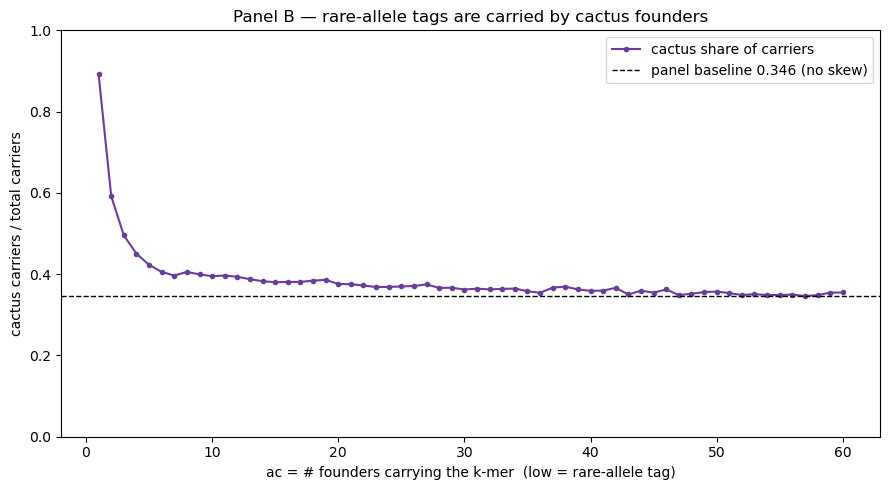

In [4]:
acmax = 60
share = np.full(acmax+1, np.nan)
for a in range(1, acmax+1):
    m = (ac == a)
    if m.sum():
        share[a] = ac_cactus[m].sum() / (a * m.sum())   # = mean cactus fraction among ac=a k-mers

fig, ax = plt.subplots(figsize=(9, 5))
xs = np.arange(1, acmax+1)
ax.plot(xs, share[1:acmax+1], '-o', ms=3, color='#6a3d9a', label='cactus share of carriers')
ax.axhline(BASELINE, color='k', ls='--', lw=1, label=f'panel baseline {BASELINE:.3f} (no skew)')
ax.set_xlabel('ac = # founders carrying the k-mer  (low = rare-allele tag)')
ax.set_ylabel('cactus carriers / total carriers')
ax.set_ylim(0, 1)
ax.set_title('Panel B — rare-allele tags are carried by cactus founders')
ax.legend()
fig.tight_layout(); fig.savefig(PLOTDIR/'carrier_axis_B_share_vs_rarity.png', dpi=130); plt.show()

## Panel C — carrier composition across the rarity spectrum

Among k-mers with `ac>=2` (so "cactus-only / PG-only / mixed" is well defined),
how the composition shifts from the rare end to the common end. Rare shared
k-mers are dominated by **cactus-only**; as k-mers get common they become
**mixed** (carried by both sides).

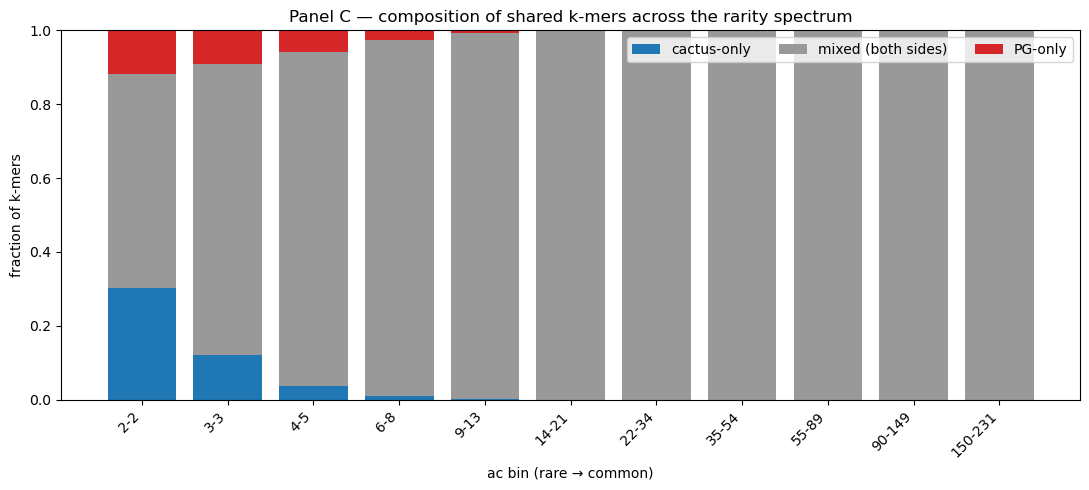

In [5]:
edges = [2,3,4,6,9,14,22,35,55,90,150, F+1]
lab, f_co, f_pg, f_mx = [], [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (ac >= lo) & (ac < hi)
    n = m.sum()
    if n == 0: continue
    co = (m & (ac_pg == 0)).sum() / n
    po = (m & (ac_cactus == 0)).sum() / n
    mx = 1 - co - po
    lab.append(f'{lo}-{hi-1}'); f_co.append(co); f_pg.append(po); f_mx.append(mx)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(lab))
ax.bar(x, f_co, color='#1f77b4', label='cactus-only')
ax.bar(x, f_mx, bottom=f_co, color='#999999', label='mixed (both sides)')
ax.bar(x, f_pg, bottom=np.array(f_co)+np.array(f_mx), color='#d62728', label='PG-only')
ax.set_xticks(x); ax.set_xticklabels(lab, rotation=45, ha='right')
ax.set_xlabel('ac bin (rare → common)'); ax.set_ylabel('fraction of k-mers')
ax.set_title('Panel C — composition of shared k-mers across the rarity spectrum')
ax.legend(ncol=3)
fig.tight_layout(); fig.savefig(PLOTDIR/'carrier_axis_C_composition.png', dpi=130); plt.show()

## Panel D — the literal sentence, in one plot

Hold bubble size fixed and vary only tag rarity. For each bubble-size bin we plot
the cactus carrier-share separately for **rare-allele tags** (`2<=ac<=10`) and
**common-allele tags** (`ac>=50`). The two lines are **flat across `m_b`** (bubble
size doesn't drive the skew) but **vertically separated** (rarity does): at every
bubble size, rare tags sit well above the baseline and common tags sit on it.

This is exactly "same bubbles, different carriers": within a bubble of any size,
cactus activates the rare tags and PG/everyone activates the common tags. We use
`ac>=2` to exclude pure private (`ac=1`) k-mers, which are the most N-poisoning
sensitive.

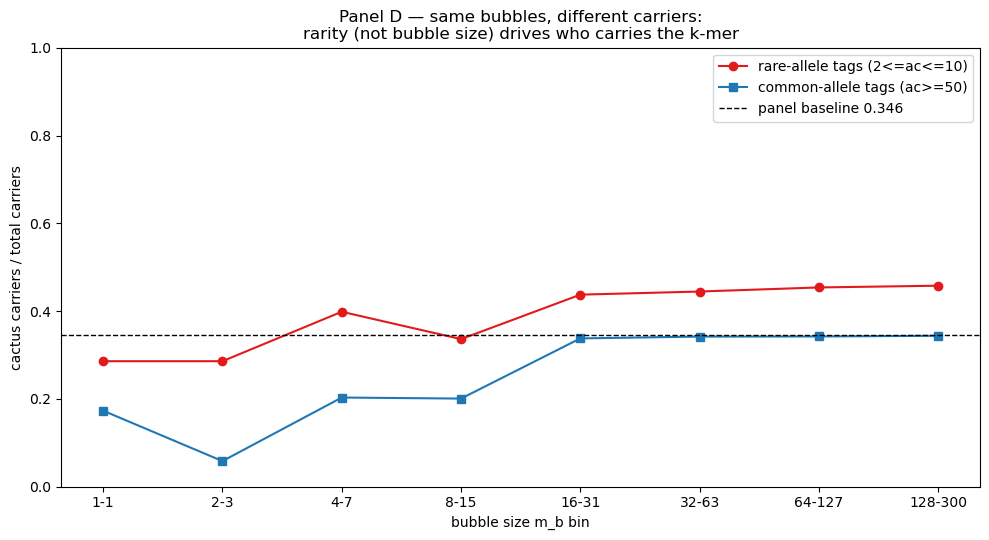

In [6]:
mb_edges = [1,2,4,8,16,32,64,128,301]
def share_in(mask):
    out = []
    for lo, hi in zip(mb_edges[:-1], mb_edges[1:]):
        m = mask & (m_b >= lo) & (m_b < hi)
        out.append(ac_cactus[m].sum()/ac[m].sum() if m.sum() else np.nan)
    return np.array(out)

rare   = (ac >= 2) & (ac <= 10)
common = (ac >= 50)
xc = [f'{lo}-{hi-1}' for lo, hi in zip(mb_edges[:-1], mb_edges[1:])]
x  = np.arange(len(xc))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(x, share_in(rare),   '-o', color='#e31a1c', label='rare-allele tags (2<=ac<=10)')
ax.plot(x, share_in(common), '-s', color='#1f78b4', label='common-allele tags (ac>=50)')
ax.axhline(BASELINE, color='k', ls='--', lw=1, label=f'panel baseline {BASELINE:.3f}')
ax.set_xticks(x); ax.set_xticklabels(xc)
ax.set_xlabel('bubble size m_b bin'); ax.set_ylabel('cactus carriers / total carriers')
ax.set_ylim(0, 1)
ax.set_title('Panel D — same bubbles, different carriers:\nrarity (not bubble size) drives who carries the k-mer')
ax.legend()
fig.tight_layout(); fig.savefig(PLOTDIR/'carrier_axis_D_money.png', dpi=130); plt.show()

## Panel E — per-founder-side rarity spectrum of carried k-mers

Flip the conditioning: of all the (founder, k-mer) carrier events on each side,
what is the rarity (`ac`) of the k-mers involved? Cactus carrier-events have a
heavier rare tail — when a cactus founder lights up a k-mer it is more often a
rare-allele tag than when a PG founder does. (Each k-mer of carrier-count `ac` is
weighted by how many cactus / PG founders carry it.)

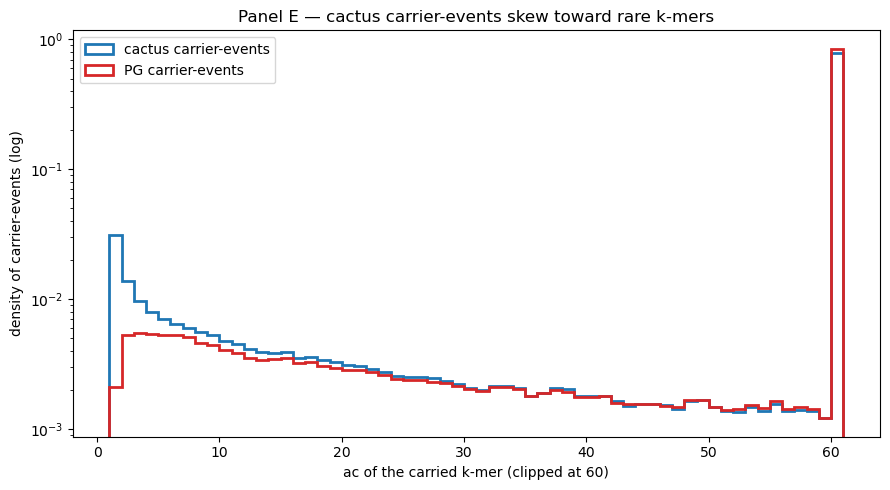

In [7]:
acclip = np.minimum(ac, 60)
bins = np.arange(1, 62)
wc = ac_cactus  # weight: # cactus carrier-events at each k-mer
wp = ac_pg
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(acclip, bins=bins, weights=wc, density=True, histtype='step', lw=2,
        color='#1f77b4', label='cactus carrier-events')
ax.hist(acclip, bins=bins, weights=wp, density=True, histtype='step', lw=2,
        color='#d62728', label='PG carrier-events')
ax.set_yscale('log')
ax.set_xlabel('ac of the carried k-mer (clipped at 60)')
ax.set_ylabel('density of carrier-events (log)')
ax.set_title('Panel E — cactus carrier-events skew toward rare k-mers')
ax.legend()
fig.tight_layout(); fig.savefig(PLOTDIR/'carrier_axis_E_perfounder_rarity.png', dpi=130); plt.show()

## Takeaway

- **Panel A** (bubble size) is balanced — cactus and PG sit in equally-sized bubbles.
- **Panels B–E** (carrier identity) show the imbalance: rare-allele tags are
  disproportionately cactus-carried; common/REF tags are at the panel baseline.

So the "missing" k-mers are not missing — they are the rare-allele tag k-mers
inside the same bubbles, activated by cactus haplotypes and not by PG ones. The
imbalance is a property of *which founders realize rare alleles*, not of bubble
geometry. **Magnitude caveat:** this matrix is `--treat-missing-as-n` ON; rebuild
N-off (or compare side-by-side) to separate real long-read-realizes-rare-alleles
biology from PG-missing-GT N-poisoning.